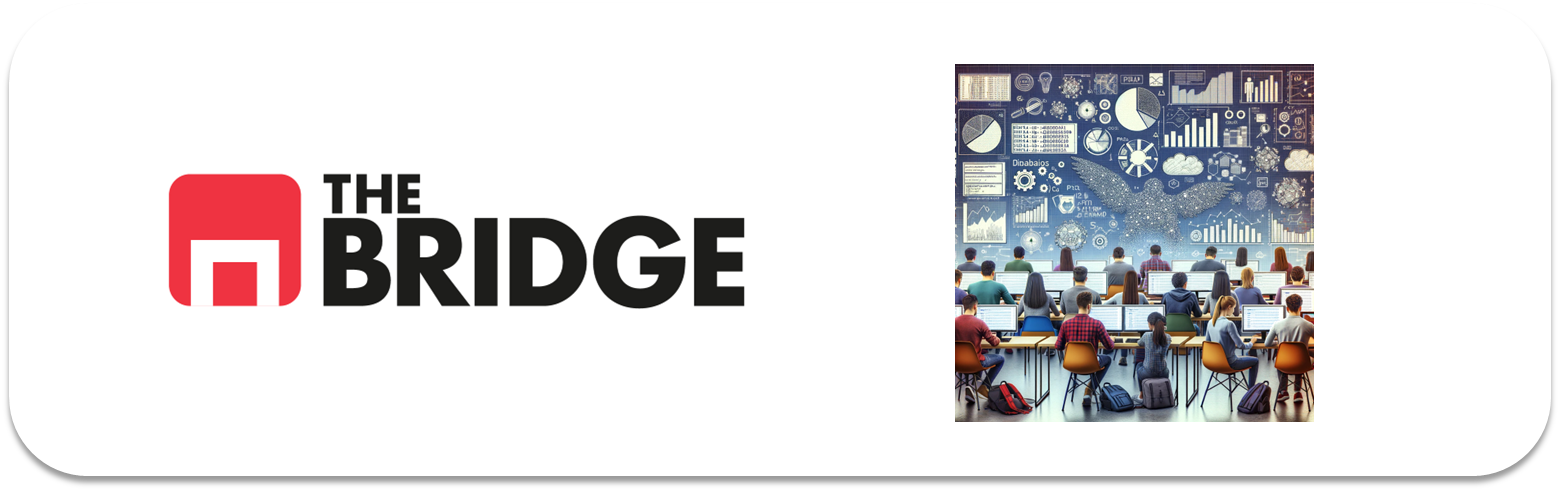

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



## 1. Carga y primer vistazo al dataset

Cargamos el dataset del Titanic y realizamos una primera inspección para conocer
su estructura, dimensiones, tipos de variables y posibles valores nulos.

In [4]:
df = pd.read_csv('data/titanic.csv')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [7]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
# porcentaje de valores nulos por columna
null_porcentage = (df.isna().mean() *100).round(2).sort_values(ascending=False)

null_porcentage


deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00
dtype: float64

## 2. Selección inicial y limpieza de variables

Se eliminan aquellas variables que presentan información redundante, fuga de
información respecto al target o un porcentaje excesivo de valores nulos:

- `alive`: contiene la misma información que la variable objetivo `survived`,
  por lo que provocaría fuga de información (data leakage).
- `class`: representa la misma información que `pclass`.
- `embark_town`: representa la misma información que `embarked`.
- `deck`: presenta un 77.22 % de valores nulos.

El resto de variables se mantienen inicialmente para analizar su relación con
la supervivencia durante el Mini-EDA.

In [12]:
df.drop(columns=["alive", "class", "embark_town", "deck"], inplace=True)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,True


## 3. Análisis de la variable objetivo: `survived`

La variable objetivo del modelo será `survived`, que indica si un pasajero
sobrevivió al Titanic:

- `0`: No sobrevivió.
- `1`: Sobrevivió.

Analizamos su distribución para comprobar si existe desbalance entre las clases,
ya que esto puede influir en la interpretación de las métricas del modelo.

In [16]:
# Distribución absoluta del target
df["survived"].value_counts()


survived
0    549
1    342
Name: count, dtype: int64

In [14]:
# Distribución porcentual del target
(df["survived"].value_counts(normalize=True) * 100).round(2)

survived
0    61.62
1    38.38
Name: proportion, dtype: float64

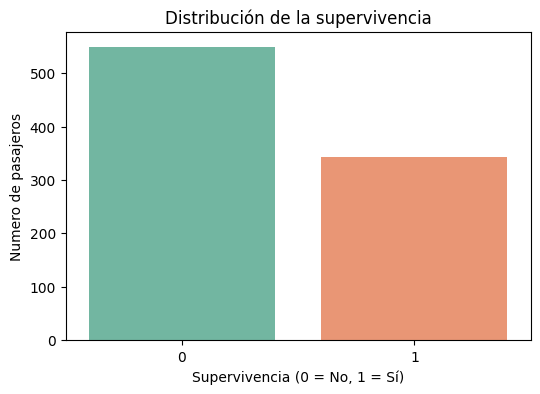

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="survived", hue="survived", palette="Set2")    

plt.title("Distribución de la supervivencia")
plt.xlabel("Supervivencia (0 = No, 1 = Sí)")
plt.ylabel("Numero de pasajeros")
plt.legend([], [], frameon=False)

plt.show()

### Conclusión sobre la distribución del target

La variable `survived` presenta cierto desbalance entre sus dos clases:

- El **61.62 %** de los pasajeros no sobrevivió (`0`).
- El **38.38 %** de los pasajeros sobrevivió (`1`).

Aunque existe una clase mayoritaria, el desbalance no es extremo. Aun así, el
`accuracy` no deberá analizarse de forma aislada, ya que un modelo que
predijera siempre la clase mayoritaria obtendría aproximadamente un **61.62 %**
de acierto sin tener realmente capacidad predictiva.

Por este motivo, la evaluación del modelo se complementará posteriormente con
la matriz de confusión y métricas como `precision`, `recall`, `F1-score` y
`ROC-AUC`.

## 4. División del dataset en Train y Test

Antes de realizar la división, se analiza la distribución de la variable
`embarked`, ya que se quiere asegurar que los conjuntos de Train y Test
mantengan una proporción similar de pasajeros procedentes de las tres ciudades
de embarque.

In [18]:
df["embarked"].value_counts(dropna=False)

embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [19]:
(df["embarked"].value_counts(normalize=True, dropna=False) * 100).round(2)

embarked
S      72.28
C      18.86
Q       8.64
NaN     0.22
Name: proportion, dtype: float64

### Distribución de la ciudad de embarque

La mayoría de los pasajeros embarcó en Southampton (`S`), representando un
72.28 % del dataset, seguido de Cherbourg (`C`) con un 18.86 % y Queenstown
(`Q`) con un 8.64 %.

La variable presenta únicamente 2 valores nulos (0.22 % del dataset). Debido
a que representan una proporción mínima y necesitamos utilizar `embarked` para
mantener una distribución similar de las ciudades en Train y Test, se eliminan
estos dos registros antes de realizar la división.

In [20]:
df.dropna(subset=["embarked"], inplace=True)

df.shape

(889, 11)

### Split estratificado por ciudad de embarque

Se divide el dataset en un 80 % para entrenamiento y un 20 % para test.

Se utiliza `stratify` sobre la variable `embarked` para mantener en ambos
conjuntos una proporción similar de pasajeros procedentes de Southampton,
Cherbourg y Queenstown.

In [ ]:
train_set, test_set = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["embarked"]
)


In [ ]:
# Comparamos la distribución de embarked en Train y Test

distribucion_embarked = pd.DataFrame({
    "Train (%)": train_set["embarked"].value_counts(normalize=True) * 100,
    "Test (%)": test_set["embarked"].value_counts(normalize=True) * 100
    }).round(2)

distribucion_embarked

,Train (%),Test (%)
embarked,,
S,72.43,72.47
C,18.85,19.10
Q,8.72,8.43


### Conclusión

- La distribución de `embarked` se mantiene prácticamente igual entre los conjuntos de entrenamiento y test. Las diferencias entre las proporciones son mínimas, por lo que la estratificación ha conservado correctamente la representación de los tres puertos de embarque.

- Esto permitirá evaluar posteriormente el modelo sobre un conjunto de test con una distribución de esta variable comparable a la utilizada durante el entrenamiento.

## 5. Construcción de las parejas X, y de Train y Test 

Una vez realizado el split, separamos la variable objetivo `survived` de las variables predictoras. 

 - `X_train` y `X_test`contiene las variables que utilizaremos para realizar las predicciones. 
 - `y_train` y `y_test`contiene el target `survived`, donde `0` representa que el pasajero no sobrevivio y `1` que sobrevivio. 

In [24]:
# Separamos las variables predictoras y el target en Train
X_train = train_set.drop(columns="survived").copy()
y_train = train_set["survived"].copy()

#Separamos las variables predictoras y el target en Test
X_test = test_set.drop(columns="survived").copy()
y_test = test_set["survived"].copy()

# Comprobamos las dimensiones de los conjuntos
dimensiones = pd.DataFrame({
    "Filas": [
        X_train.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_test.shape[0]
    ],
    "Columnas": [
        X_train.shape[1],
        X_test.shape[1],
        1,
        1
    ]
}, index=["X_train", "X_test", "y_train", "y_test"])

dimensiones

,Filas,Columnas
X_train,711,10
X_test,178,10
y_train,711,1
y_test,178,1


## Conclusión

- Las parejas `X, y`se han construido correctamente. Los conjuntos de entrenamiento contienen 711 registros y los de test 178, manteniendo en ambos casos la correspondencia entre las variables predictoras y su target.
Además, `X_train` y `X_test`  contienen las mismas 10 variables predictoras por lo que podemos continuar con el procesamiento de los datos. 

## 6. Imputación de valores nulos

Una vez separados los conjuntos de entrenamiento y test, analizamos los valores nulos presentes en las variables predictoras.

La imputación se realizará utilizando únicamente la información del conjunto de entrenamiento. Los valores calculados en `X_train` se guardarán y posteriormente se aplicarán a `X_test`, evitando así introducir información del conjunto de test durante la preparación del modelo.

In [25]:
# comprobamos los valores nulos en los conjuntos de Train y Test
nulos = pd.DataFrame({
    "Train": X_train.isnull().sum(),
    "Train (%)": (X_train.isnull().mean() * 100).round(2),
    "Test": X_test.isnull().sum(),
    "Test (%)": (X_test.isnull().mean() * 100).round(2)
})

#Mostramos Unicamente las variables que tienen valores nulos en Train o Test
nulos = nulos[(nulos["Train"] > 0) | (nulos["Test"] > 0)]

nulos

,Train,Train (%),Test,Test (%)
age,138,19.41,39,21.91


### Análisis de la variable `age`

Dado que `age` es la única variable que presenta valores nulos, analizamos su distribución en el conjunto de entrenamiento antes de decidir cómo realizar la imputación.

Se comparan sus principales medidas de tendencia central y su distribución para comprobar si la media resulta adecuada como valor de imputación.

In [26]:
# Calculamos las principales medidas de tendencia central de age en Train
age_stats = pd.DataFrame({
    "Valor": [
        X_train["age"].mean(),
        X_train["age"].median()
    ]
}, index=["Media", "Mediana"]).round(2)

age_stats

,Valor
Media,29.71
Mediana,28.00


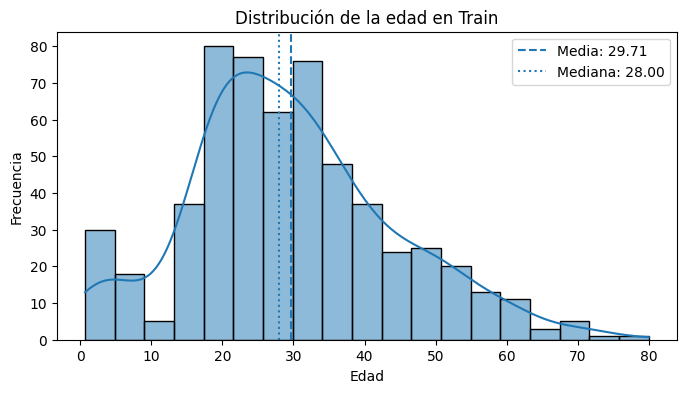

In [27]:
# Visualizamos la distribución de age en Train
plt.figure(figsize=(8, 4))

sns.histplot(data=X_train, x="age", kde=True)

plt.axvline(
    X_train["age"].mean(),
    linestyle="--",
    label=f"Media: {X_train['age'].mean():.2f}"
)

plt.axvline(
    X_train["age"].median(),
    linestyle=":",
    label=f"Mediana: {X_train['age'].median():.2f}"
)

plt.title("Distribución de la edad en Train")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

### Decisión de imputación

La variable `age` presenta una distribución ligeramente asimétrica hacia la derecha. La media en el conjunto de entrenamiento es de **29.71 años**, mientras que la mediana es de **28 años**, por lo que ambas medidas son relativamente próximas.

Siguiendo las indicaciones del ejercicio, se utilizará la **media de `age` calculada exclusivamente sobre el conjunto de entrenamiento** para imputar sus valores nulos.

Este valor se guardará para utilizarlo también en `X_test`, evitando calcular información a partir del conjunto de test y, por tanto, posibles fugas de información (*data leakage*).

In [28]:
# Guardamos la media de age calculada únicamente con Train
age_mean = X_train["age"].mean()

# Imputamos los valores nulos de Train
X_train["age"] = X_train["age"].fillna(age_mean)

# Aplicamos en Test la misma media obtenida de Train
X_test["age"] = X_test["age"].fillna(age_mean)

In [29]:
# Comprobamos que no quedan valores nulos
nulos_despues = pd.DataFrame({
    "Train": X_train.isnull().sum(),
    "Test": X_test.isnull().sum()
})

nulos_despues[nulos_despues.sum(axis=1) > 0]

,Train,Test


### Conclusión

- Tras analizar los valores ausentes, se identificó `age` como la única variable predictora con datos faltantes: 138 registros (19.41 %) en Train y 39 (21.91 %) en Test.

- La distribución de la edad presenta una ligera asimetría positiva, con una media de 29.71 años y una mediana de 28 años. Siguiendo las indicaciones del ejercicio, se utilizó la media calculada exclusivamente sobre el conjunto de entrenamiento para realizar la imputación.

- La misma media obtenida en Train se aplicó posteriormente a Test, evitando utilizar información del conjunto de evaluación durante el procesamiento y reduciendo así el riesgo de *data leakage*.

- Finalmente, se comprobó que no quedan valores nulos en ninguno de los dos conjuntos, por lo que los datos están preparados para continuar con el análisis exploratorio de las variables predictoras.

## 7. Mini-EDA y selección de features

Antes de entrenar el modelo se realiza un análisis exploratorio sobre el conjunto de entrenamiento para estudiar el comportamiento de las variables predictoras y su posible relación con la supervivencia.

El análisis se realiza únicamente sobre los datos de Train, manteniendo el conjunto de Test reservado para la evaluación final del modelo.

Se analizarán por separado las variables numéricas y categóricas, prestando especial atención a:

- La distribución de las variables.
- Su relación con el target `survived`.
- Posibles relaciones o redundancias entre features.
- La utilidad potencial de cada variable para el modelo.

A partir de estos resultados se seleccionarán y justificarán las variables que se utilizarán posteriormente en la regresión logística.

In [30]:
# Reconstruimos temporalmente Train con el target para realizar el Mini-EDA
df_eda = X_train.copy()
df_eda["survived"] = y_train

# Resumen de las variables predictoras
resumen_features = pd.DataFrame({
    "Tipo": X_train.dtypes.astype(str),
    "Valores únicos": X_train.nunique(),
    "Nulos": X_train.isnull().sum()
})

resumen_features

,Tipo,Valores únicos,Nulos
pclass,int64,3,0
sex,object,2,0
age,float64,83,0
sibsp,int64,7,0
parch,int64,6,0
fare,float64,221,0
embarked,object,3,0
who,object,3,0
adult_male,bool,2,0
alone,bool,2,0


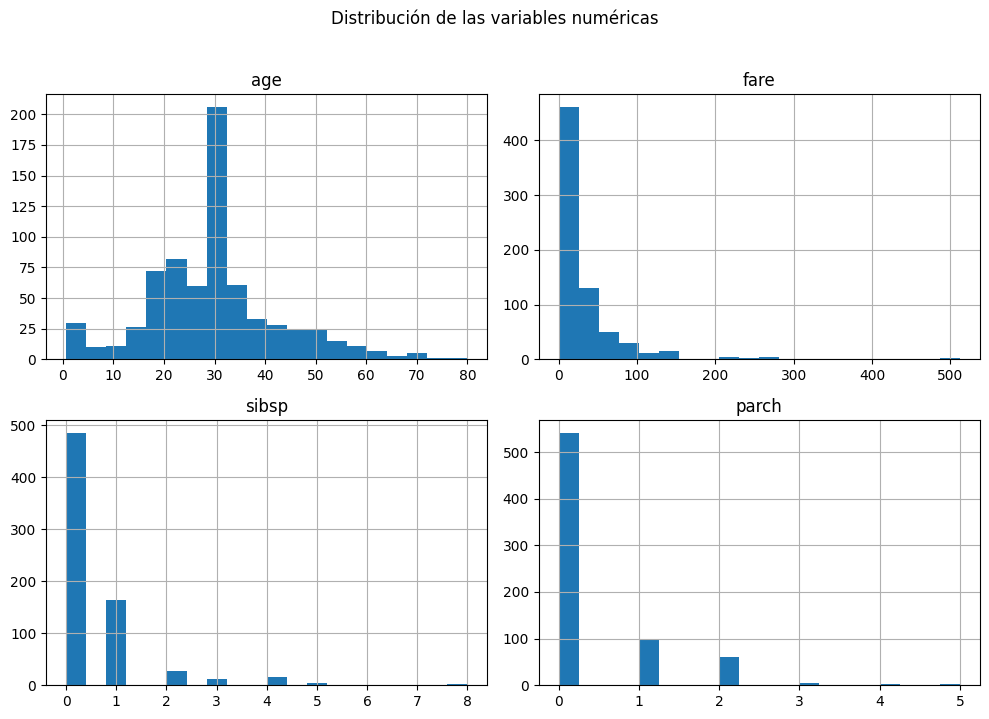

In [31]:
# Variables numéricas para el análisis
features_num = ["age", "fare", "sibsp", "parch"]

# Visualizamos sus distribuciones
X_train[features_num].hist(figsize=(10, 7), bins=20)

plt.suptitle("Distribución de las variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

### Análisis de las distribuciones numéricas

Las variables numéricas presentan comportamientos diferentes:

- **`age`** concentra la mayor parte de los pasajeros entre edades jóvenes y adultas. Se observa un pico alrededor de los 30 años, influido también por la imputación de los valores nulos mediante la media del conjunto de entrenamiento.
- **`fare`** presenta una distribución claramente asimétrica hacia la derecha. La mayoría de los pasajeros pagó tarifas relativamente bajas, mientras que existen algunos valores considerablemente elevados.
- **`sibsp`** está fuertemente concentrada en 0 y 1, indicando que la mayoría de los pasajeros viajaba sin hermanos/cónyuge o únicamente con uno.
- **`parch`** también se concentra principalmente en 0, seguido de 1 y 2, por lo que la mayoría viajaba sin padres o hijos a bordo.

Estas diferencias de distribución y escala se tendrán en cuenta posteriormente durante el tratamiento de las variables previo al modelado.

### 7.2. Análisis bivariante de las variables numéricas respecto a `survived`

Se analiza la relación entre las variables numéricas y la supervivencia para identificar posibles diferencias entre los pasajeros que sobrevivieron y los que no.

Este análisis permitirá valorar qué variables pueden aportar información útil al modelo antes de realizar la selección final de features.

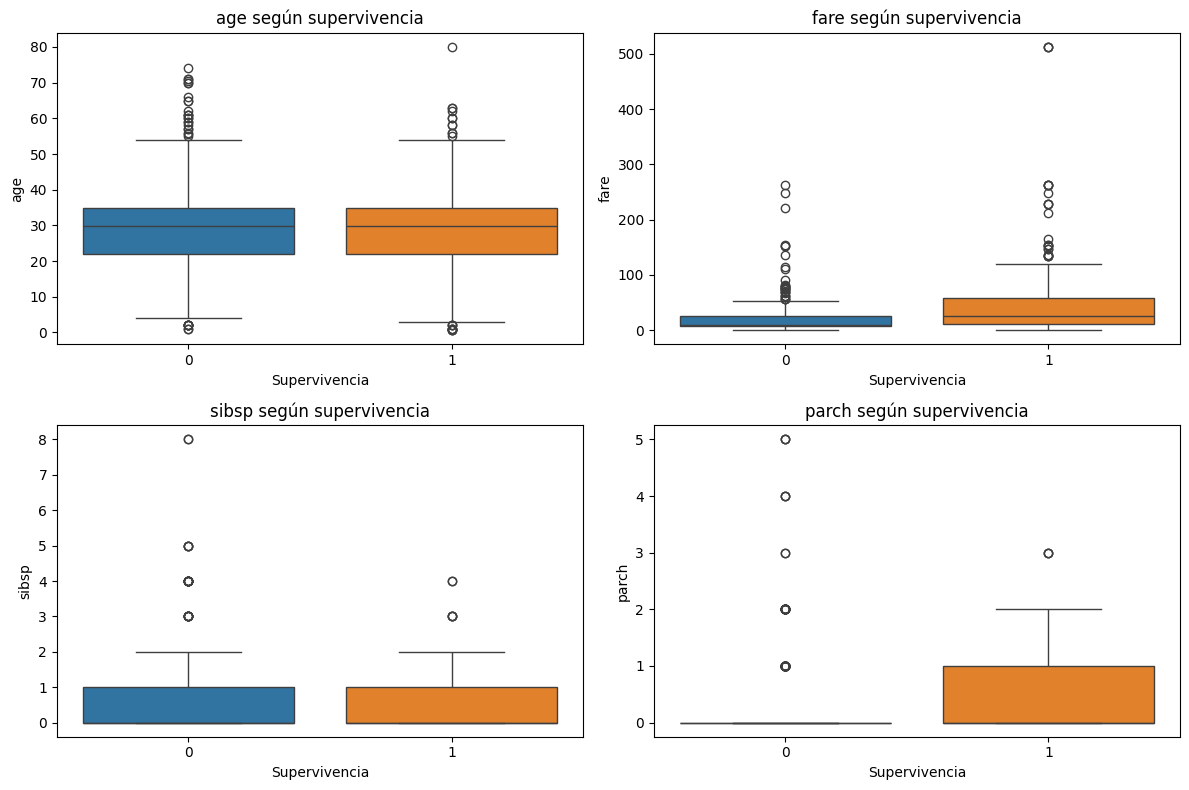

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), features_num):
    sns.boxplot(
        data=df_eda,
        x="survived",
        y=col,
        hue="survived",
        ax=ax,
        legend=False
    )
    
    ax.set_title(f"{col} según supervivencia")
    ax.set_xlabel("Supervivencia")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [33]:
resumen_num_survived = df_eda.groupby("survived")[features_num].agg(
    ["mean", "median"]
).round(2)

resumen_num_survived

age          fare        sibsp        parch       
           mean median   mean median  mean median  mean median
survived                                                      
0         30.20  29.71  20.85   9.84  0.50    0.0  0.31    0.0
1         28.92  29.71  49.17  25.93  0.49    0.0  0.46    0.0

#### Conclusiones del análisis numérico

El análisis bivariante muestra diferencias en el comportamiento de algunas variables respecto a la supervivencia:

- **`fare`** presenta la diferencia más clara. Los pasajeros que sobrevivieron pagaron, en promedio, tarifas superiores (49.17 frente a 20.85), y también presentan una mediana mayor (25.93 frente a 9.84). Esto sugiere que la tarifa puede aportar información relevante para predecir la supervivencia.
- **`age`** presenta distribuciones bastante similares entre ambos grupos. La edad media es ligeramente inferior entre los supervivientes, aunque la diferencia no parece especialmente marcada. Además, debe tenerse en cuenta que parte de la distribución está condicionada por la imputación realizada previamente.
- **`sibsp`** muestra valores medios prácticamente iguales entre supervivientes y no supervivientes, por lo que de forma aislada no se aprecia una relación clara.
- **`parch`** presenta un valor medio algo superior entre los supervivientes, aunque la fuerte concentración de observaciones en cero dificulta extraer una conclusión únicamente a partir del boxplot.

Por tanto, `fare` muestra inicialmente la relación más evidente con el target entre las variables numéricas. No obstante, por el momento no se descarta ninguna variable únicamente a partir de este análisis, ya que su utilidad final puede depender también de su interacción con el resto de variables.

### 7.3. Análisis bivariante de las variables categóricas respecto a `survived`

A continuación se analiza la relación entre las variables categóricas y la supervivencia.

Para facilitar la comparación, se calcula la **tasa de supervivencia de cada categoría**, es decir, la proporción de pasajeros que sobrevivieron dentro de cada grupo.

Este análisis permitirá identificar qué variables presentan diferencias relevantes entre sus categorías y pueden aportar información al modelo.

In [34]:
# Variables categóricas para el análisis
features_cat = ["pclass", "sex", "embarked", "who", "adult_male", "alone"]

# Comprobamos sus categorías
for col in features_cat:
    print(f"\n{col}:")
    print(X_train[col].value_counts())


pclass:
pclass
3    405
1    163
2    143
Name: count, dtype: int64

sex:
sex
male      460
female    251
Name: count, dtype: int64

embarked:
embarked
S    515
C    134
Q     62
Name: count, dtype: int64

who:
who
man      433
woman    217
child     61
Name: count, dtype: int64

adult_male:
adult_male
True     433
False    278
Name: count, dtype: int64

alone:
alone
True     430
False    281
Name: count, dtype: int64


In [35]:
# Calculamos la tasa de supervivencia por categoría
for col in features_cat:
    tasa = (
        df_eda.groupby(col)["survived"]
        .agg(["count", "mean"])
        .rename(columns={
            "count": "Pasajeros",
            "mean": "Tasa_supervivencia"
        })
    )

    tasa["Tasa_supervivencia"] = (
        tasa["Tasa_supervivencia"] * 100
    ).round(2)

    print(f"\n--- {col} ---")
    display(tasa)


--- pclass ---


,Pasajeros,Tasa_supervivencia
pclass,,
1,163,63.19
2,143,47.55
3,405,24.69



--- sex ---


,Pasajeros,Tasa_supervivencia
sex,,
female,251,75.70
male,460,17.61



--- embarked ---


,Pasajeros,Tasa_supervivencia
embarked,,
C,134,55.97
Q,62,41.94
S,515,33.01



--- who ---


,Pasajeros,Tasa_supervivencia
who,,
child,61,57.38
man,433,15.70
woman,217,77.42



--- adult_male ---


,Pasajeros,Tasa_supervivencia
adult_male,,
False,278,73.02
True,433,15.70



--- alone ---


,Pasajeros,Tasa_supervivencia
alone,,
False,281,50.18
True,430,30.23


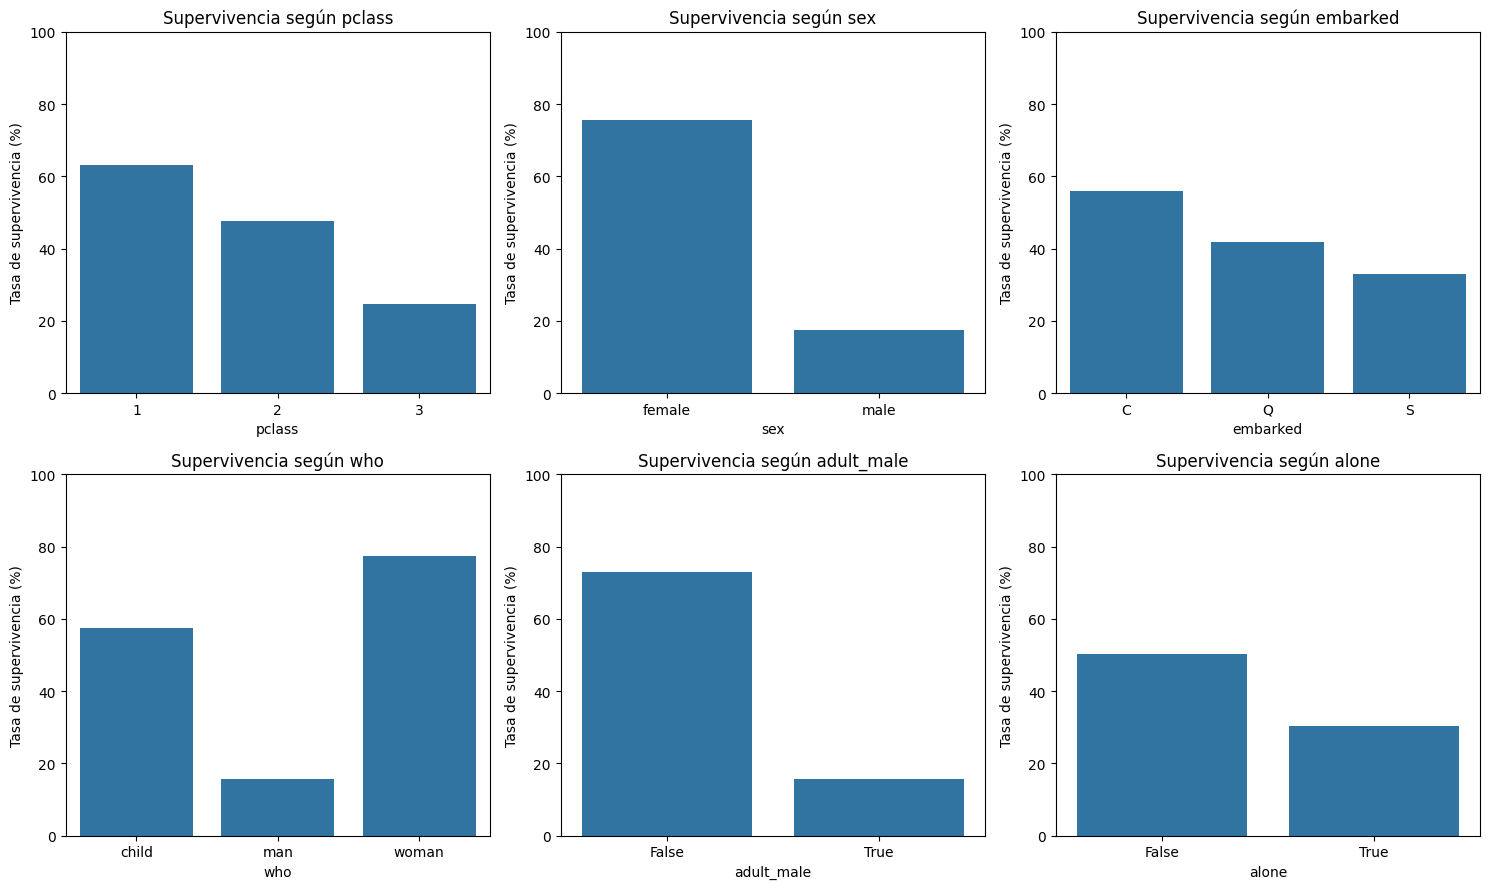

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, col in zip(axes.flatten(), features_cat):

    tasa = (
        df_eda.groupby(col)["survived"]
        .mean()
        .mul(100)
        .reset_index(name="Tasa_supervivencia")
    )

    sns.barplot(
        data=tasa,
        x=col,
        y="Tasa_supervivencia",
        ax=ax
    )

    ax.set_title(f"Supervivencia según {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Tasa de supervivencia (%)")
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

#### Conclusiones del análisis categórico

El análisis muestra diferencias claras en las tasas de supervivencia entre las distintas categorías:

- **`pclass`** presenta una relación clara con la supervivencia. La tasa disminuye progresivamente desde primera clase (63.19 %) hasta tercera clase (24.69 %).
- **`sex`** muestra una de las diferencias más importantes: el 75.70 % de las mujeres sobrevivió, frente al 17.61 % de los hombres.
- **`embarked`** también presenta diferencias entre categorías. Los pasajeros embarcados en Cherbourg muestran una mayor tasa de supervivencia (55.97 %) que los embarcados en Queenstown (41.94 %) y Southampton (33.01 %).
- **`who`** diferencia claramente los grupos: las mujeres presentan la mayor supervivencia (77.42 %), seguidas de los niños (57.38 %), mientras que los hombres muestran una tasa considerablemente inferior (15.70 %).
- **`adult_male`** también muestra una diferencia muy marcada, con una supervivencia del 15.70 % entre los hombres adultos frente al 73.02 % del resto de pasajeros.
- **`alone`** muestra que los pasajeros que viajaban acompañados presentan una tasa de supervivencia superior (50.18 %) a quienes viajaban solos (30.23 %).

En conjunto, las variables categóricas parecen aportar información relevante para explicar la supervivencia. Sin embargo, algunas variables como `sex`, `who` y `adult_male` contienen información parcialmente redundante, por lo que esta relación deberá considerarse antes de realizar la selección definitiva de variables para el modelo.

In [37]:
# Analizamos la relación entre variables categóricas potencialmente redundantes
pd.crosstab(
    [X_train["sex"], X_train["who"]],
    X_train["adult_male"],
    margins=True
)

adult_male    False  True  All
sex    who                    
female child     34     0   34
       woman    217     0  217
male   child     27     0   27
       man        0   433  433
All             278   433  711

#### Redundancia entre `sex`, `who` y `adult_male`

- La tabla cruzada confirma una fuerte relación entre estas tres variables.
- Los 433 pasajeros identificados como hombres adultos (`adult_male = True`) coinciden exactamente con los registros clasificados como `male` y `man`. Por otro lado, mujeres y niños presentan siempre `adult_male = False`.
- Por tanto, `adult_male` contiene información que ya está representada en gran medida por las variables `sex` y `who`. Mantener simultáneamente las tres variables introduciría información redundante en el modelo.
- Esta relación se tendrá en cuenta durante la selección final de features.

### 7.4. Selección de features

A partir de los resultados obtenidos en el Mini-EDA, se realizará la selección de las variables que se utilizarán para entrenar el modelo.

La selección tendrá en cuenta tanto la relación observada entre cada variable y `survived` como la posible existencia de información redundante entre algunas de ellas.

Antes de realizar la selección definitiva, se analizará la relación entre `sibsp`, `parch` y `alone`, ya que estas variables representan información relacionada con los acompañantes y la composición familiar del pasajero.

In [38]:
# Relación entre las variables familiares y alone
pd.crosstab(
    [X_train["sibsp"], X_train["parch"]],
    X_train["alone"],
    margins=True
)

alone        False  True  All
sibsp parch                  
0     0          0   430  430
      1         31     0   31
      2         21     0   21
      3          1     0    1
      4          1     0    1
      5          1     0    1
1     0         93     0   93
      1         48     0   48
      2         16     0   16
      3          3     0    3
      4          2     0    2
      5          2     0    2
2     0         16     0   16
      1          7     0    7
      2          4     0    4
      3          1     0    1
3     0          2     0    2
      1          5     0    5
      2          6     0    6
4     1          7     0    7
      2          8     0    8
5     2          4     0    4
8     2          2     0    2
All            281   430  711

#### Relación entre acompañantes y `alone`

La tabla cruzada muestra que `alone` está directamente determinada por las variables `sibsp` y `parch`. Para visualizar esta relación de forma más sencilla, se calcula el número de familiares que acompañaban al pasajero a partir de ambas variables.

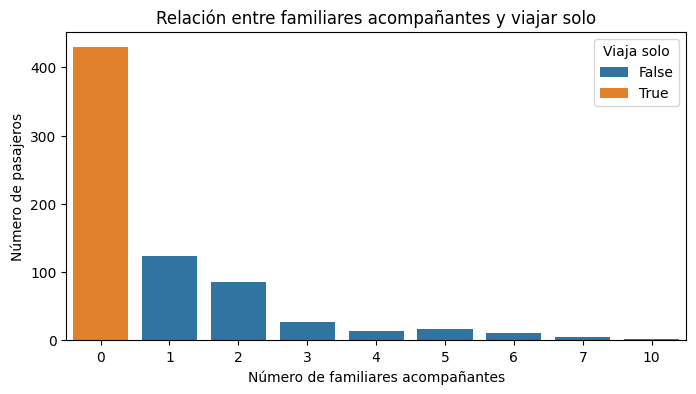

In [39]:
# Creamos temporalmente el número de familiares acompañantes
family_members = X_train["sibsp"] + X_train["parch"]

# Tabla auxiliar para la visualización
family_analysis = pd.DataFrame({
    "Familiares": family_members,
    "alone": X_train["alone"]
})

plt.figure(figsize=(8, 4))

sns.countplot(
    data=family_analysis,
    x="Familiares",
    hue="alone"
)

plt.title("Relación entre familiares acompañantes y viajar solo")
plt.xlabel("Número de familiares acompañantes")
plt.ylabel("Número de pasajeros")
plt.legend(title="Viaja solo")

plt.show()

#### Conclusión sobre las variables familiares

- La visualización confirma que `alone` está completamente determinada por `sibsp` y `parch`.
- Todos los pasajeros que no viajaban con hermanos/cónyuge ni padres/hijos (`sibsp = 0` y `parch = 0`) aparecen como `alone = True`. En cambio, cuando existe al menos un familiar acompañante, `alone = False`.
- Por tanto, incluir simultáneamente `sibsp`, `parch` y `alone` introduciría información redundante en el modelo.
- Además, la suma de `sibsp` y `parch` permite representar el número de familiares que acompañaban al pasajero, por lo que posteriormente se podrá valorar la creación de una única variable que sintetice esta información.

#### Decisión sobre las variables familiares

- A partir del análisis realizado se decide no utilizar simultáneamente `sibsp`, `parch` y `alone`, ya que contienen información relacionada.
- En lugar de conservar únicamente `alone`, se optará por combinar `sibsp` y `parch` en una nueva variable que represente el **tamaño del grupo familiar del pasajero**.
- Esta alternativa conserva más información que `alone`, ya que permite distinguir no solo si el pasajero viajaba acompañado, sino también el número de familiares con los que viajaba.
- La nueva variable se construirá posteriormente durante el tratamiento de las features como:
`family_size = sibsp + parch + 1` donde el `+1` representa al propio pasajero.
- Una vez creada `family_size`, las variables originales `sibsp`, `parch` y `alone` no se utilizarán conjuntamente en el modelo, evitando así introducir información redundante.

## 8. Tratamiento de las variables

Una vez finalizado el Mini-EDA y seleccionadas las variables que se utilizarán en el modelo, se procede a transformar las features para que puedan ser utilizadas adecuadamente por la regresión logística.

A partir de las conclusiones anteriores se realizarán los siguientes tratamientos:

- Creación de `family_size` a partir de `sibsp` y `parch`.
- Eliminación de variables redundantes.
- Codificación de las variables categóricas.
- Revisión de la distribución y escala de las variables numéricas.
- Escalado de las variables cuando resulte conveniente.

Todas las decisiones y transformaciones se definirán utilizando el conjunto de entrenamiento y posteriormente se aplicarán de la misma forma al conjunto de test, evitando fugas de información (*data leakage*).

### 8.1. Creación de la variable `family_size`

Se crea una nueva variable que representa el tamaño del grupo familiar del pasajero a bordo.

Para ello se suman el número de hermanos/cónyuges (`sibsp`), el número de padres/hijos (`parch`) y el propio pasajero:

`family_size = sibsp + parch + 1`

Esta variable conserva más información que `alone`, ya que permite diferenciar entre distintos tamaños de grupo familiar y no únicamente entre viajar solo o acompañado.

In [40]:
# Creamos family_size
X_train["family_size"] = X_train["sibsp"] + X_train["parch"] + 1
X_test["family_size"] = X_test["sibsp"] + X_test["parch"] + 1

# Comprobamos la nueva variable
X_train["family_size"].value_counts().sort_index()

family_size
1     430
2     124
3      85
4      26
5      13
6      17
7      10
8       4
11      2
Name: count, dtype: int64

#### Comprobación de `family_size`

La nueva variable se ha generado correctamente. Los 430 pasajeros con `family_size = 1` coinciden con los pasajeros que anteriormente estaban identificados como viajeros solos (`alone = True`).

A diferencia de `alone`, la nueva variable conserva información sobre el tamaño del grupo familiar, permitiendo distinguir entre pasajeros solos y pasajeros que viajaban en grupos familiares de diferentes tamaños.

### 8.2. Eliminación de variables redundantes

Una vez creada `family_size`, se eliminan las variables cuya información ya está representada por otras features seleccionadas:

- `sibsp` y `parch`: su información se ha combinado en `family_size`.
- `alone`: se deriva directamente de `sibsp` y `parch` y queda representada por `family_size`.
- `adult_male`: presenta una fuerte redundancia con `sex` y `who`.
- `who`: contiene información parcialmente derivada de `sex` y `age`.

Se conservan `pclass`, `sex`, `age`, `fare`, `embarked` y la nueva variable `family_size`.

In [41]:
# Variables que no utilizaremos en el modelo
features_drop = ["sibsp", "parch", "alone", "adult_male", "who"]

X_train.drop(columns=features_drop, inplace=True)
X_test.drop(columns=features_drop, inplace=True)

# Comprobamos las features seleccionadas
X_train.head()

,pclass,sex,age,fare,embarked,family_size
46,3,male,29.710454,15.500,Q,2
230,1,female,35.000000,83.475,S,2
657,3,female,32.000000,15.500,Q,3
888,3,female,29.710454,23.450,S,4
809,1,female,33.000000,53.100,S,2


### 8.3. Tratamiento de las variables categóricas

Tras la selección de features, todavía tenemos dos variables categóricas que no pueden introducirse directamente en el modelo de regresión logística:

- `sex`: variable categórica binaria.
- `embarked`: variable categórica con tres categorías correspondientes a los puertos de embarque.

Estas variables deben transformarse a una representación numérica antes del entrenamiento.

Para ello utilizaremos **One-Hot Encoding**, evitando introducir un orden artificial entre las categorías. Además, eliminaremos una de las categorías de referencia (`drop_first=True`) para evitar redundancia entre las variables dummy.

In [42]:
# Comprobamos las categorías antes de realizar la codificación
for col in ["sex", "embarked"]:
    print(f"\n--- {col} ---")
    print(X_train[col].value_counts())


--- sex ---
sex
male      460
female    251
Name: count, dtype: int64

--- embarked ---
embarked
S    515
C    134
Q     62
Name: count, dtype: int64


In [43]:
# Codificamos las variables categóricas
X_train = pd.get_dummies(
    X_train,
    columns=["sex", "embarked"],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=["sex", "embarked"],
    drop_first=True,
    dtype=int
)

# Aseguramos que Test tenga exactamente las mismas columnas que Train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Comprobamos el resultado
X_train.head()

,pclass,age,fare,family_size,sex_male,embarked_Q,embarked_S
46,3,29.710454,15.500,2,1,1,0
230,1,35.000000,83.475,2,0,0,1
657,3,32.000000,15.500,3,0,1,0
888,3,29.710454,23.450,4,0,0,1
809,1,33.000000,53.100,2,0,0,1


In [44]:
print("Features Train:")
print(X_train.columns.tolist())

print("\nFeatures Test:")
print(X_test.columns.tolist())

print("\nMismas features:", X_train.columns.equals(X_test.columns))

Features Train:
['pclass', 'age', 'fare', 'family_size', 'sex_male', 'embarked_Q', 'embarked_S']

Features Test:
['pclass', 'age', 'fare', 'family_size', 'sex_male', 'embarked_Q', 'embarked_S']

Mismas features: True


#### Conclusión de la codificación

- Tras aplicar One-Hot Encoding, todas las variables categóricas han quedado representadas numéricamente.
- `female` actúa como categoría de referencia para `sex`, mientras que Cherbourg (`C`) es la categoría de referencia para `embarked`. Por tanto, estas categorías quedan representadas cuando las variables dummy correspondientes toman valor 0.
- Train y Test contienen exactamente las mismas 7 features, por lo que la estructura de ambos conjuntos se mantiene consistente para las siguientes etapas del procesamiento.

### 8.4. Tratamiento de las variables numéricas

Antes de realizar el escalado se revisan las variables numéricas seleccionadas para determinar si necesitan alguna transformación adicional.

Del Mini-EDA realizado anteriormente se observó que `fare` presenta una distribución fuertemente asimétrica hacia la derecha, con algunos valores considerablemente elevados.

Por este motivo, se estudiará una transformación logarítmica de `fare` antes del escalado. Esta transformación puede reducir la influencia de los valores extremos y comprimir su rango manteniendo el orden de los valores.

También se revisará `family_size`, mientras que `age` se mantendrá inicialmente en su escala original.

`pclass` se conservará como variable ordinal, ya que sus valores representan las tres clases de pasajero.

In [45]:
# Revisamos los valores de fare antes de aplicar una transformación logarítmica
resumen_fare = pd.DataFrame({
    "Valor": [
        X_train["fare"].min(),
        X_train["fare"].max(),
        X_train["fare"].mean(),
        X_train["fare"].median()
    ]
}, index=["Mínimo", "Máximo", "Media", "Mediana"])

resumen_fare.round(2)

,Valor
Mínimo,0.00
Máximo,512.33
Media,31.65
Mediana,14.00


#### 8.4.1. Transformación de `fare`

La variable `fare` presenta una marcada asimetría positiva. En Train, la tarifa media es de 31.65, mientras que la mediana es de 14.00, y se alcanza un valor máximo de 512.33.

Esta diferencia entre media y mediana, junto con el amplio rango observado, confirma la influencia de valores elevados sobre la distribución.

Además, existen pasajeros con `fare = 0`, por lo que no resulta adecuado aplicar directamente el logaritmo natural. Se evaluará una transformación `log1p`, equivalente a calcular `log(1 + fare)`, que permite incluir los valores iguales a cero.

Antes de modificar definitivamente la variable, se comparará gráficamente su distribución original con la distribución obtenida tras la transformación.

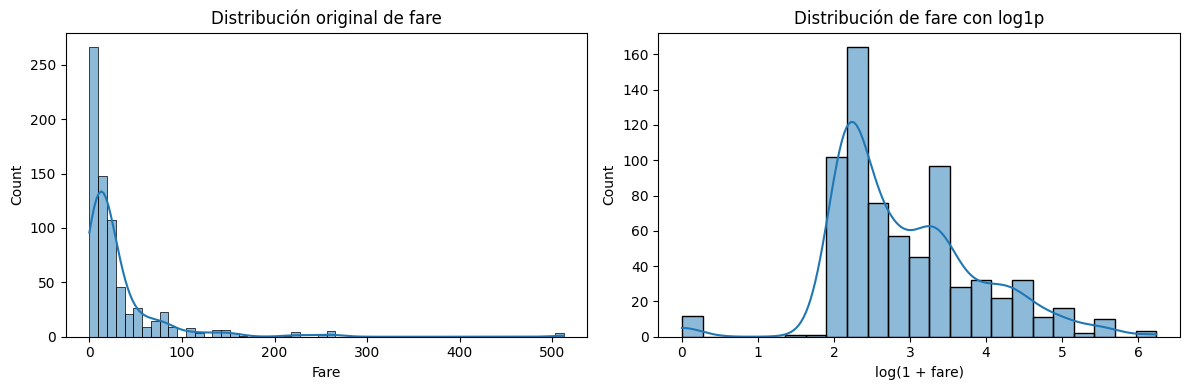

In [46]:
# Creamos temporalmente la transformación logarítmica
fare_log = np.log1p(X_train["fare"])

# Comparamos ambas distribuciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    X_train["fare"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribución original de fare")
axes[0].set_xlabel("Fare")

sns.histplot(
    fare_log,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Distribución de fare con log1p")
axes[1].set_xlabel("log(1 + fare)")

plt.tight_layout()
plt.show()

#### Conclusión sobre la transformación de `fare`

- La comparación gráfica muestra que la distribución original de `fare` presenta una fuerte asimetría positiva, provocada por la concentración de pasajeros con tarifas bajas y la presencia de algunos valores considerablemente elevados.
- La transformación `log1p` reduce notablemente esta asimetría y comprime los valores extremos, permitiendo trabajar con una escala más equilibrada.
- Aunque la distribución transformada no es completamente normal, este no es un requisito de la regresión logística. El objetivo de la transformación es reducir la influencia de la escala y de los valores extremos.
- Por este motivo, se decide utilizar `log1p(fare)` como representación de la tarifa antes del escalado de las variables numéricas.

In [47]:
# Aplicamos la transformación logarítmica a fare
X_train["fare"] = np.log1p(X_train["fare"])
X_test["fare"] = np.log1p(X_test["fare"])

# Comprobamos el resultado
X_train["fare"].describe().round(2)

count    711.00
mean       2.93
std        0.97
min        0.00
25%        2.19
50%        2.71
75%        3.44
max        6.24
Name: fare, dtype: float64

#### 8.4.2. Revisión de `family_size`

La nueva variable `family_size` es una variable discreta y presenta una mayor concentración en grupos familiares pequeños.

Antes de decidir su tratamiento definitivo, se analizará su relación con la variable objetivo. Esto permitirá comprobar si la supervivencia presenta un comportamiento aproximadamente progresivo con el tamaño familiar o si existen diferencias específicas entre pasajeros solos, familias pequeñas y grupos familiares numerosos.

In [48]:
family_analysis = pd.DataFrame({
    "family_size": X_train["family_size"],
    "survived": y_train
})

family_summary = family_analysis.groupby("family_size").agg(
    Pasajeros=("survived", "size"),
    Tasa_supervivencia=("survived", "mean")
)

family_summary["Tasa_supervivencia"] = (
    family_summary["Tasa_supervivencia"] * 100
).round(2)

family_summary

,Pasajeros,Tasa_supervivencia
family_size,,
1,430,30.23
2,124,54.03
3,85,55.29
4,26,73.08
5,13,23.08
6,17,17.65
7,10,20.00
8,4,0.00
11,2,0.00


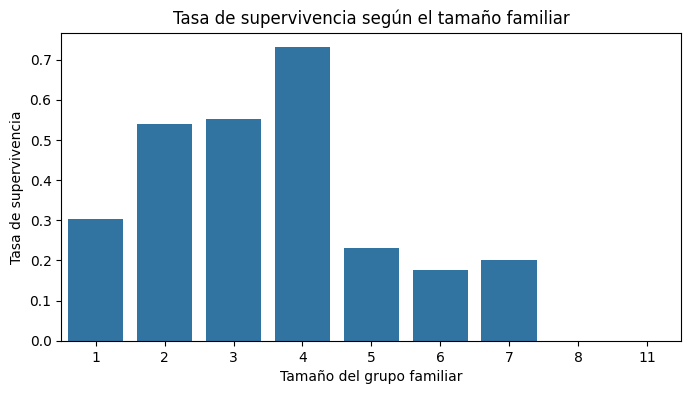

In [49]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=family_analysis,
    x="family_size",
    y="survived",
    errorbar=None
)

plt.title("Tasa de supervivencia según el tamaño familiar")
plt.xlabel("Tamaño del grupo familiar")
plt.ylabel("Tasa de supervivencia")

plt.show()

#### Conclusión sobre `family_size`

- La relación entre `family_size` y la supervivencia no presenta un comportamiento lineal.
- Los pasajeros que viajaban solos (`family_size = 1`) muestran una tasa de supervivencia del 30.23 %. En cambio, los grupos familiares pequeños, especialmente entre 2 y 4 personas, presentan tasas considerablemente superiores, alcanzando el 73.08 % para los grupos de tamaño 4.
- A partir de grupos familiares de 5 personas, la tasa de supervivencia vuelve a disminuir. No obstante, los tamaños familiares más elevados contienen pocas observaciones, por lo que sus porcentajes deben interpretarse con cautela.
- Este comportamiento sugiere que utilizar `family_size` únicamente como una variable numérica continua podría no representar adecuadamente su relación con el target. Por ello, se agrupará el tamaño familiar en categorías que permitan representar este patrón de forma más adecuada.

#### 8.4.3. Agrupación del tamaño familiar

A partir del análisis anterior, `family_size` se transforma en una variable categórica con tres grupos:

- `Solo`: pasajero que viajaba sin familiares (`family_size = 1`).
- `Small`: grupo familiar de entre 2 y 4 personas.
- `Large`: grupo familiar de 5 o más personas.

Esta agrupación permite representar el comportamiento no lineal observado en la tasa de supervivencia y, al mismo tiempo, evita generar categorías con un número demasiado reducido de observaciones.

In [50]:
# Función para agrupar el tamaño familiar
def categorize_family_size(size):
    if size == 1:
        return "Solo"
    elif size <= 4:
        return "Small"
    else:
        return "Large"

# Aplicamos exactamente la misma transformación a Train y Test
X_train["family_group"] = X_train["family_size"].apply(categorize_family_size)
X_test["family_group"] = X_test["family_size"].apply(categorize_family_size)

# Comprobamos la distribución en Train
X_train["family_group"].value_counts()

family_group
Solo     430
Small    235
Large     46
Name: count, dtype: int64

#### Comprobación de `family_group`

Antes de sustituir definitivamente `family_size`, se comprueba si los tres grupos creados conservan el patrón de supervivencia observado en el análisis anterior.

In [51]:
family_group_analysis = pd.DataFrame({
    "family_group": X_train["family_group"],
    "survived": y_train
})

family_group_summary = family_group_analysis.groupby("family_group").agg(
    Pasajeros=("survived", "size"),
    Tasa_supervivencia=("survived", "mean")
)

family_group_summary["Tasa_supervivencia"] = (
    family_group_summary["Tasa_supervivencia"] * 100
).round(2)

family_group_summary

,Pasajeros,Tasa_supervivencia
family_group,,
Large,46,17.39
Small,235,56.60
Solo,430,30.23


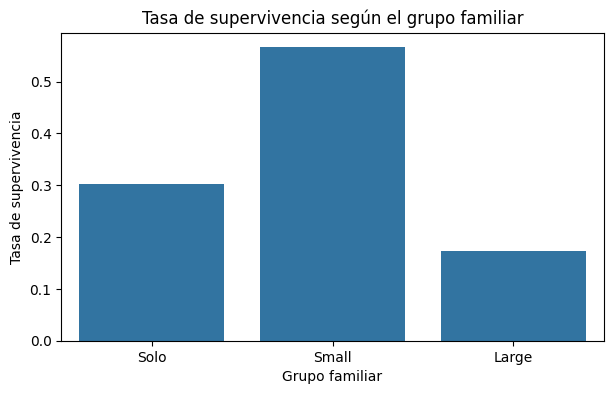

In [52]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=family_group_analysis,
    x="family_group",
    y="survived",
    order=["Solo", "Small", "Large"],
    errorbar=None
)

plt.title("Tasa de supervivencia según el grupo familiar")
plt.xlabel("Grupo familiar")
plt.ylabel("Tasa de supervivencia")

plt.show()

#### Conclusión sobre `family_group`

- La agrupación confirma el patrón observado previamente con `family_size`.
- Los pasajeros pertenecientes a grupos familiares pequeños (`Small`) presentan la mayor tasa de supervivencia, con un **56.60 %**, frente al **30.23 %** de quienes viajaban solos (`Solo`) y el **17.39 %** de quienes pertenecían a grupos familiares grandes (`Large`).
- Esto confirma que la relación entre el tamaño familiar y la supervivencia no es lineal. Por este motivo, se utilizará `family_group` como variable categórica en lugar de `family_size`, ya que representa mejor el patrón observado y evita mantener categorías con muy pocos pasajeros.

In [53]:
# Eliminamos family_size, ya representada mediante family_group
X_train.drop(columns="family_size", inplace=True)
X_test.drop(columns="family_size", inplace=True)

In [54]:
print("Train:")
print(X_train["family_group"].value_counts())

print("\nTest:")
print(X_test["family_group"].value_counts())

Train:
family_group
Solo     430
Small    235
Large     46
Name: count, dtype: int64

Test:
family_group
Solo     105
Small     57
Large     16
Name: count, dtype: int64


### Codificación de `family_group`

La variable `family_group` es categórica y contiene tres categorías: `Solo`, `Small` y `Large`.

Se ha comprobado que las tres categorías están presentes tanto en Train como en Test. Para poder utilizar esta variable en la regresión logística se realizará una codificación mediante variables dummy.

Al igual que con las variables categóricas anteriores, se utilizará `drop_first=True` para evitar introducir información redundante.

In [55]:
# Codificamos family_group
X_train = pd.get_dummies(
    X_train,
    columns=["family_group"],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=["family_group"],
    drop_first=True,
    dtype=int
)

# Aseguramos que Test tenga exactamente las mismas columnas que Train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Comprobamos el resultado
print("Features Train:")
print(X_train.columns.tolist())

print("\nFeatures Test:")
print(X_test.columns.tolist())

print("\nMismas features:", X_train.columns.equals(X_test.columns))

Features Train:
['pclass', 'age', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'family_group_Small', 'family_group_Solo']

Features Test:
['pclass', 'age', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'family_group_Small', 'family_group_Solo']

Mismas features: True


### Comprobación final de las features antes del escalado

Tras realizar la selección, creación y codificación de variables, comprobamos el estado final de las features antes de aplicar el escalado.

En este punto:

- `fare` ha sido transformada mediante `log1p` para reducir su fuerte asimetría.
- `sex`, `embarked` y `family_group` han sido codificadas mediante variables dummy.
- Train y Test contienen exactamente las mismas variables predictoras.
- Las variables dummy toman únicamente valores 0 y 1, por lo que no será necesario escalarlas.
- Revisaremos las variables numéricas restantes para decidir cuáles conviene estandarizar.

In [56]:
# Revisamos el estado final de las features
X_train.describe().round(2)

,pclass,age,fare,sex_male,embarked_Q,embarked_S,family_group_Small,family_group_Solo
count,711.00,711.00,711.00,711.00,711.00,711.00,711.00,711.00
mean,2.34,29.71,2.93,0.65,0.09,0.72,0.33,0.60
std,0.83,13.04,0.97,0.48,0.28,0.45,0.47,0.49
min,1.00,0.67,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,22.00,2.19,0.00,0.00,0.00,0.00,0.00
50%,3.00,29.71,2.71,1.00,0.00,1.00,0.00,1.00
75%,3.00,35.00,3.44,1.00,0.00,1.00,1.00,1.00
max,3.00,80.00,6.24,1.00,1.00,1.00,1.00,1.00


### Escalado de las variables numéricas

Una vez revisadas las escalas de las variables seleccionadas, se decide estandarizar `age` y `fare`.

- `age` presenta un rango considerablemente mayor que las variables binarias.
- `fare`, aunque previamente ha sido transformada mediante `log1p`, también se estandarizará para situarla en una escala comparable.
- `pclass` se mantiene sin escalar, ya que representa una variable ordinal con tres categorías.
- Las variables dummy se mantienen en su codificación 0/1.

Para evitar *data leakage*, el `StandardScaler` se ajustará (`fit`) **exclusivamente con los datos de Train**. Posteriormente, ese mismo escalador se utilizará para transformar tanto Train como Test.

In [57]:
from sklearn.preprocessing import StandardScaler

# Variables numéricas que vamos a escalar
features_scale = ["age", "fare"]

# Creamos el escalador
scaler = StandardScaler()

# El scaler aprende únicamente de Train
scaler.fit(X_train[features_scale])

# Transformamos Train
X_train[features_scale] = scaler.transform(
    X_train[features_scale]
)

# Transformamos Test utilizando el MISMO scaler
X_test[features_scale] = scaler.transform(
    X_test[features_scale]
)

# Comprobamos el resultado
X_train.describe().round(2)

,pclass,age,fare,sex_male,embarked_Q,embarked_S,family_group_Small,family_group_Solo
count,711.00,711.00,711.00,711.00,711.00,711.00,711.00,711.00
mean,2.34,0.00,-0.00,0.65,0.09,0.72,0.33,0.60
std,0.83,1.00,1.00,0.48,0.28,0.45,0.47,0.49
min,1.00,-2.23,-3.04,0.00,0.00,0.00,0.00,0.00
25%,2.00,-0.59,-0.78,0.00,0.00,0.00,0.00,0.00
50%,3.00,0.00,-0.23,1.00,0.00,1.00,0.00,1.00
75%,3.00,0.41,0.53,1.00,0.00,1.00,1.00,1.00
max,3.00,3.86,3.43,1.00,1.00,1.00,1.00,1.00


### Conclusiones del procesamiento de features

Tras el análisis y tratamiento de las variables, el conjunto de datos queda preparado para el entrenamiento del modelo.

- Se conservaron `pclass`, `age`, `fare`, `sex`, `embarked` y la nueva información familiar creada a partir de `sibsp` y `parch`.
- `fare` fue transformada mediante `log1p` para reducir su fuerte asimetría.
- Las variables categóricas se codificaron mediante variables dummy.
- La información familiar se resumió mediante `family_group`, diferenciando entre pasajeros que viajaban solos, grupos familiares pequeños y grupos familiares grandes.
- `age` y `fare` fueron estandarizadas mediante `StandardScaler`.
- El escalador fue ajustado exclusivamente con Train y posteriormente aplicado a Test, evitando *data leakage*.
- Train y Test mantienen exactamente las mismas variables predictoras.

Con estas transformaciones disponemos de un conjunto de features numéricas y preparado para entrenar el modelo de regresión logística.

## 9. Construcción del modelo de Regresión Logística

Una vez finalizado el procesamiento de las variables, entrenamos un modelo de regresión logística utilizando el conjunto de entrenamiento.

El objetivo del modelo será estimar la probabilidad de que un pasajero pertenezca a la clase positiva (`survived = 1`) en función de las características seleccionadas.

Inicialmente utilizaremos los parámetros por defecto del modelo, aumentando únicamente `max_iter` para asegurar que el algoritmo disponga de suficientes iteraciones para alcanzar la convergencia.

In [58]:
from sklearn.linear_model import LogisticRegression

# Creamos el modelo
log_reg = LogisticRegression(max_iter=5000)

# Entrenamos únicamente con Train
log_reg.fit(X_train, y_train)

log_reg

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [59]:
print("Clases del modelo:", log_reg.classes_)
print("Intercepto:", log_reg.intercept_)
print("Coeficientes:")
print(log_reg.coef_)

Clases del modelo: [0 1]
Intercepto: [1.42539151]
Coeficientes:
[[-0.77134849 -0.3503155   0.2769204  -2.60558783  0.15171972 -0.27066422
   1.69453418  1.73805782]]


## 10. EXTRA: Análisis de los pesos e importancia de las features

La regresión logística permite analizar los coeficientes asociados a cada variable predictora.

El signo del coeficiente indica la dirección de la relación con la clase positiva (`survived = 1`):

- Un coeficiente positivo se asocia con un aumento de los *log-odds* de supervivencia.
- Un coeficiente negativo se asocia con una disminución de los *log-odds* de supervivencia.
- La magnitud del coeficiente permite valorar la intensidad de su efecto dentro de la escala y codificación utilizadas.

En las variables dummy, los coeficientes deben interpretarse siempre respecto a la categoría utilizada como referencia.

In [60]:
# Creamos una tabla con los coeficientes del modelo
coeficientes = pd.DataFrame({
    "Feature": X_train.columns,
    "Coeficiente": log_reg.coef_[0]
})

coeficientes["Abs_coeficiente"] = coeficientes["Coeficiente"].abs()

coeficientes = coeficientes.sort_values(
    "Abs_coeficiente",
    ascending=False
).reset_index(drop=True)

coeficientes.round(3)

,Feature,Coeficiente,Abs_coeficiente
0,sex_male,-2.606,2.606
1,family_group_Solo,1.738,1.738
2,family_group_Small,1.695,1.695
3,pclass,-0.771,0.771
4,age,-0.350,0.350
5,fare,0.277,0.277
6,embarked_S,-0.271,0.271
7,embarked_Q,0.152,0.152


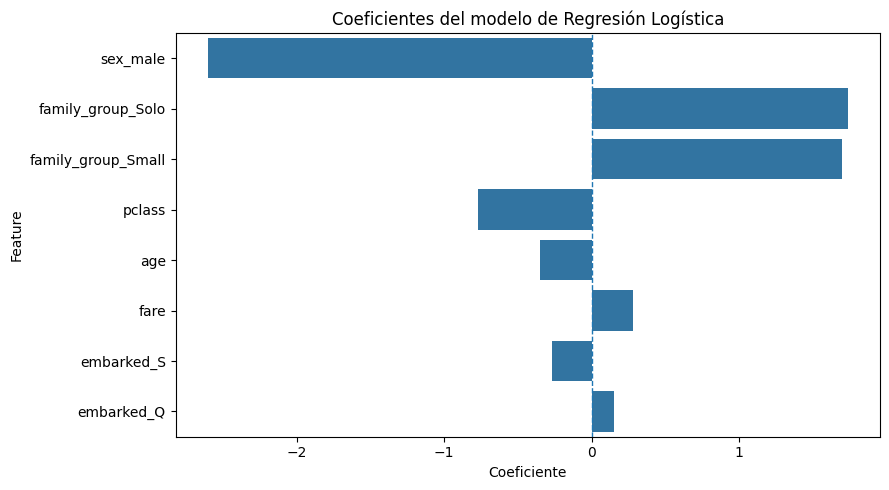

In [61]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=coeficientes,
    x="Coeficiente",
    y="Feature"
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Coeficientes del modelo de Regresión Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Conclusiones sobre los coeficientes del modelo

Los coeficientes muestran diferencias claras en la influencia de las variables sobre la predicción de supervivencia.

- **`sex_male`** presenta el coeficiente negativo de mayor magnitud (`-2.606`). Manteniendo constantes el resto de variables, ser hombre se asocia con una menor probabilidad estimada de supervivencia respecto a ser mujer, que actúa como categoría de referencia.

- **`family_group_Small`** (`1.695`) y **`family_group_Solo`** (`1.738`) presentan coeficientes positivos respecto a la categoría de referencia `Large`. Este resultado debe interpretarse con cautela: no significa que viajar solo sea la situación con mayor supervivencia, sino que tanto viajar solo como pertenecer a un grupo familiar pequeño se asocian con una mayor probabilidad estimada de supervivencia que pertenecer a un grupo familiar grande. En el análisis previo, los grupos pequeños fueron los que presentaron la mayor tasa de supervivencia observada.

- **`pclass`** presenta un coeficiente negativo (`-0.771`). Al aumentar su valor de 1 a 3 se pasa de primera a tercera clase, por lo que el resultado indica que viajar en clases inferiores se asocia con una menor probabilidad estimada de supervivencia.

- **`age`** presenta un coeficiente negativo (`-0.350`), indicando que un aumento de la edad se asocia con una reducción de la probabilidad estimada de supervivencia.

- **`fare`** presenta un coeficiente positivo (`0.277`), por lo que tarifas más elevadas se asocian con una mayor probabilidad estimada de supervivencia.

- Las variables relacionadas con el puerto de embarque presentan coeficientes de menor magnitud. `embarked_S` muestra una asociación negativa (`-0.271`) y `embarked_Q` una asociación positiva pequeña (`0.152`), ambas respecto a Cherbourg (`C`), que actúa como categoría de referencia.

En conjunto, el sexo, el grupo familiar y la clase del pasajero son las variables que muestran los efectos de mayor magnitud dentro del modelo. Estos coeficientes representan asociaciones utilizadas por el modelo para realizar sus predicciones y no deben interpretarse como relaciones causales.

## 11. Procesamiento del conjunto de Test

Durante el procesamiento de las features se han aplicado al conjunto de Test las mismas transformaciones definidas a partir del conjunto de entrenamiento.

En concreto:

- Los valores nulos de `age` se imputaron utilizando la media calculada exclusivamente sobre Train.
- Se creó `family_size` a partir de `sibsp` y `parch` y posteriormente `family_group`, utilizando los mismos criterios definidos en Train.
- Se eliminaron las variables descartadas durante la selección de features.
- Las variables categóricas se transformaron mediante la misma estrategia de codificación utilizada en Train.
- `fare` se transformó mediante `log1p`.
- `age` y `fare` se estandarizaron utilizando el `StandardScaler` ajustado exclusivamente con Train.
- Finalmente, se aseguró que `X_test` tuviera exactamente las mismas columnas y en el mismo orden que `X_train`.

Por tanto, no es necesario volver a transformar el conjunto de Test. Únicamente realizamos una comprobación final antes de utilizarlo para evaluar el modelo.

In [62]:
# Comprobación final de Train y Test antes de evaluar el modelo
comprobacion = pd.DataFrame({
    "Train": [
        X_train.shape[0],
        X_train.shape[1],
        X_train.isnull().sum().sum()
    ],
    "Test": [
        X_test.shape[0],
        X_test.shape[1],
        X_test.isnull().sum().sum()
    ]
}, index=["Filas", "Columnas", "Valores nulos"])

comprobacion

,Train,Test
Filas,711,178
Columnas,8,8
Valores nulos,0,0


In [63]:
print("Mismas features:", X_train.columns.equals(X_test.columns))

Mismas features: True


## 12. Evaluación del modelo

Una vez entrenado el modelo y preparado el conjunto de Test, evaluaremos su comportamiento tanto sobre los datos de entrenamiento como sobre datos no utilizados durante el ajuste.

La evaluación incluirá:

- Predicciones y probabilidades estimadas por el modelo.
- Comparación del rendimiento entre Train y Test.
- Comparación frente a un modelo base (*baseline*).
- Matrices de confusión.
- Métricas de clasificación: accuracy, precision, recall y F1-score.
- Curva ROC y área bajo la curva (ROC-AUC).

El objetivo no será únicamente obtener un valor elevado de accuracy, sino comprobar cómo se comporta el modelo en ambas clases y valorar su capacidad de generalización.

In [64]:
# Predicciones de clase
y_pred_train = log_reg.predict(X_train)
y_pred_test = log_reg.predict(X_test)

# Probabilidades de pertenecer a cada clase
y_proba_train = log_reg.predict_proba(X_train)
y_proba_test = log_reg.predict_proba(X_test)

print("Clases:", log_reg.classes_)
print("Dimensión probabilidades Train:", y_proba_train.shape)
print("Dimensión probabilidades Test:", y_proba_test.shape)

Clases: [0 1]
Dimensión probabilidades Train: (711, 2)
Dimensión probabilidades Test: (178, 2)


In [65]:
# Comparamos algunos valores reales, predicciones y probabilidades
comparacion_predicciones = pd.DataFrame({
    "Real": y_test.reset_index(drop=True),
    "Prediccion": y_pred_test,
    "Prob_No_sobrevive": y_proba_test[:, 0],
    "Prob_Sobrevive": y_proba_test[:, 1]
})

comparacion_predicciones.head(10).round(3)

,Real,Prediccion,Prob_No_sobrevive,Prob_Sobrevive
0,0,0,0.904,0.096
1,1,1,0.296,0.704
2,0,1,0.377,0.623
3,1,1,0.222,0.778
4,1,1,0.065,0.935
5,1,1,0.255,0.745
6,0,0,0.780,0.220
7,0,0,0.886,0.114
8,0,0,0.831,0.169
9,0,0,0.686,0.314


### 12.2 Comparación de rendimiento entre Train y Test

Como primera aproximación evaluamos el `accuracy` obtenido por el modelo tanto en Train como en Test.

La comparación entre ambos conjuntos permite detectar posibles diferencias de rendimiento y obtener una primera aproximación a la capacidad de generalización del modelo.

Sin embargo, el `accuracy` no debe interpretarse de forma aislada. Dado que la variable objetivo presenta cierto desbalance entre pasajeros que sobrevivieron y no sobrevivieron, compararemos también el resultado con un modelo base que predijera siempre la clase mayoritaria.

In [66]:
from sklearn.metrics import accuracy_score

# Accuracy en Train y Test
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

# Baseline: proporción de la clase mayoritaria en Train y Test
baseline_train = y_train.value_counts(normalize=True).max()
baseline_test = y_test.value_counts(normalize=True).max()

resultados_accuracy = pd.DataFrame({
    "Train": [acc_train, baseline_train],
    "Test": [acc_test, baseline_test]
}, index=["Accuracy modelo", "Baseline clase mayoritaria"])

(resultados_accuracy * 100).round(2)

,Train,Test
Accuracy modelo,81.43,78.09
Baseline clase mayoritaria,61.88,61.24


#### Primera valoración del rendimiento

El modelo obtiene un **accuracy del 81.43 % en Train** y del **78.09 % en Test**, superando claramente el rendimiento que se obtendría prediciendo siempre la clase mayoritaria, cuyo baseline se sitúa alrededor del 62 %.

La diferencia entre Train y Test es de aproximadamente **3.34 puntos porcentuales**. Esta caída moderada es esperable al evaluar sobre datos no utilizados durante el entrenamiento y, por el momento, no muestra una señal clara de sobreajuste.

Sin embargo, el accuracy no permite conocer qué tipos de errores está cometiendo el modelo. Por ello, es necesario continuar la evaluación mediante la matriz de confusión y las métricas de precision, recall y F1-score.

### 12.3 Matrices de confusión

La matriz de confusión permite analizar los aciertos y errores del modelo diferenciando entre las dos clases.

En nuestro problema:

- **TN (True Negative):** pasajero que no sobrevivió y el modelo predijo que no sobreviviría.
- **FP (False Positive):** pasajero que no sobrevivió, pero el modelo predijo que sobreviviría.
- **FN (False Negative):** pasajero que sobrevivió, pero el modelo predijo que no sobreviviría.
- **TP (True Positive):** pasajero que sobrevivió y el modelo predijo correctamente su supervivencia.

Se comparan las matrices obtenidas en Train y Test para observar si el patrón de errores se mantiene en datos no utilizados durante el entrenamiento.

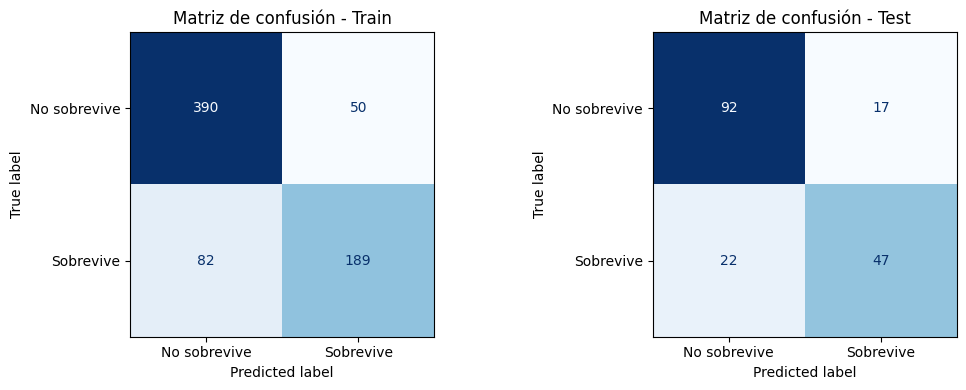

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrices de confusión
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=["No sobrevive", "Sobrevive"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Matriz de confusión - Train")

ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["No sobrevive", "Sobrevive"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)

axes[1].set_title("Matriz de confusión - Test")

plt.tight_layout()
plt.show()

In [68]:
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()
tn_test, fp_test, fn_test, tp_test = cm_test.ravel()

confusion_resumen = pd.DataFrame({
    "Train": [tn_train, fp_train, fn_train, tp_train],
    "Test": [tn_test, fp_test, fn_test, tp_test]
}, index=["TN", "FP", "FN", "TP"])

confusion_resumen

,Train,Test
TN,390,92
FP,50,17
FN,82,22
TP,189,47


#### Interpretación de la matriz de confusión

La matriz de confusión permite observar con mayor detalle el tipo de errores cometidos por el modelo.

En el conjunto de **Test**:

- **92 pasajeros** fueron correctamente clasificados como no supervivientes (TN).
- **47 pasajeros** fueron correctamente clasificados como supervivientes (TP).
- **17 pasajeros** fueron clasificados como supervivientes cuando realmente no sobrevivieron (FP).
- **22 pasajeros** que realmente sobrevivieron fueron clasificados como no supervivientes (FN).

El modelo presenta, por tanto, un mayor número de **falsos negativos que de falsos positivos**. Esto indica que tiene algo más de dificultad para identificar a todos los pasajeros que realmente sobrevivieron que para reconocer a los que no sobrevivieron.

El patrón es similar en Train, donde también se observan más falsos negativos (82) que falsos positivos (50). Esto sugiere que este comportamiento no aparece únicamente en el conjunto de Test, sino que forma parte del patrón de clasificación aprendido por el modelo.

Para cuantificar estas diferencias entre clases continuaremos la evaluación mediante las métricas de **precision, recall y F1-score**.

### 12.4 Métricas de clasificación

Para complementar el análisis de las matrices de confusión calculamos las principales métricas de clasificación para Train y Test.

Se analizarán especialmente:

- **Precision:** de los pasajeros predichos como pertenecientes a una clase, qué proporción fue clasificada correctamente.
- **Recall:** de los pasajeros que realmente pertenecen a una clase, qué proporción consiguió identificar el modelo.
- **F1-score:** media armónica entre precision y recall, que permite valorar conjuntamente ambas métricas.
- **Accuracy:** proporción total de predicciones correctas.

Estas métricas permiten evaluar el comportamiento del modelo por clase y son especialmente importantes cuando la distribución del target no está perfectamente balanceada.

In [69]:
from sklearn.metrics import classification_report

print("CLASSIFICATION REPORT - TRAIN")
print(classification_report(
    y_train,
    y_pred_train,
    target_names=["No sobrevive", "Sobrevive"]
))

print("\nCLASSIFICATION REPORT - TEST")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["No sobrevive", "Sobrevive"]
))

CLASSIFICATION REPORT - TRAIN
              precision    recall  f1-score   support

No sobrevive       0.83      0.89      0.86       440
   Sobrevive       0.79      0.70      0.74       271

    accuracy                           0.81       711
   macro avg       0.81      0.79      0.80       711
weighted avg       0.81      0.81      0.81       711


CLASSIFICATION REPORT - TEST
              precision    recall  f1-score   support

No sobrevive       0.81      0.84      0.83       109
   Sobrevive       0.73      0.68      0.71        69

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.77       178
weighted avg       0.78      0.78      0.78       178



#### Interpretación de las métricas de clasificación

Los resultados muestran un comportamiento relativamente estable entre los conjuntos de Train y Test, aunque se observa una ligera disminución de las métricas al evaluar sobre datos no utilizados durante el entrenamiento.

En **Test**, el modelo obtiene un accuracy del **78 %**. Sin embargo, el análisis por clase muestra diferencias importantes:

- Para los pasajeros que **no sobrevivieron**, se obtiene una precision de **0.81**, un recall de **0.84** y un F1-score de **0.83**.
- Para los pasajeros que **sobrevivieron**, la precision es de **0.73**, el recall de **0.68** y el F1-score de **0.71**.

Por tanto, el modelo presenta un mejor comportamiento identificando pasajeros que no sobrevivieron. El menor recall de la clase `Sobrevive` confirma lo observado en la matriz de confusión: existe una mayor dificultad para detectar a todos los supervivientes, produciéndose 22 falsos negativos en Test.

El **macro average** presenta un F1-score de **0.77**, mientras que el **weighted average** alcanza **0.78**. La pequeña diferencia entre ambos se debe a que el promedio ponderado tiene en cuenta el mayor número de pasajeros pertenecientes a la clase `No sobrevive`.

La diferencia moderada entre los resultados de Train y Test no muestra, por el momento, indicios importantes de sobreajuste y sugiere una capacidad de generalización razonable.

### 12.5 Curva ROC y ROC-AUC

La curva ROC permite evaluar la capacidad del modelo para distinguir entre las dos clases utilizando diferentes umbrales de decisión.

Para construirla no se utilizan directamente las clases predichas, sino las **probabilidades estimadas para la clase positiva (`survived = 1`)**.

La curva representa:

- **TPR (True Positive Rate o Recall)** en el eje Y.
- **FPR (False Positive Rate)** en el eje X.

El área bajo la curva (**ROC-AUC**) resume la capacidad discriminativa del modelo. Un valor próximo a 1 indica una buena separación entre clases, mientras que un valor próximo a 0.5 representa un comportamiento similar al azar.

In [70]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidad de pertenecer a la clase positiva (survived = 1)
y_proba_positive = y_proba_test[:, 1]

# Calculamos los puntos de la curva ROC para distintos umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_proba_positive)

# Área bajo la curva
roc_auc = roc_auc_score(y_test, y_proba_positive)

print("ROC-AUC:", round(roc_auc, 3))

ROC-AUC: 0.851


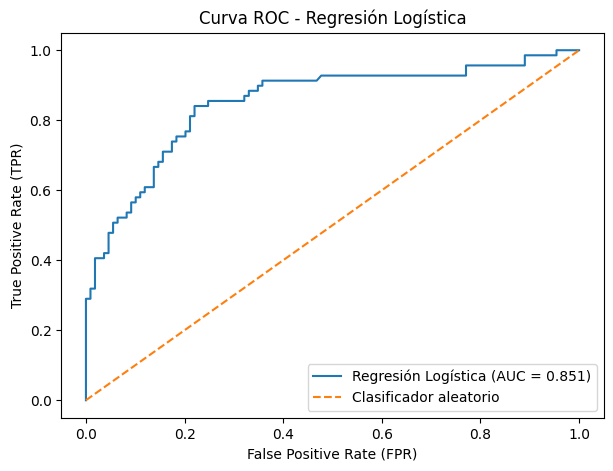

In [71]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Regresión Logística (AUC = {roc_auc:.3f})"
)

# Línea de referencia de un clasificador aleatorio
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()

plt.show()

#### Interpretación de la curva ROC

- El modelo obtiene un **ROC-AUC de 0.851**, lo que indica una buena capacidad para discriminar entre pasajeros que sobrevivieron y pasajeros que no sobrevivieron.
- La curva ROC se encuentra claramente por encima de la diagonal correspondiente a un clasificador aleatorio, cuyo AUC sería aproximadamente 0.5. Por tanto, el modelo presenta una capacidad de clasificación considerablemente superior al azar.
- Es importante recordar que la curva ROC evalúa el comportamiento del modelo para **diferentes umbrales de decisión**. Cada punto de la curva representa una combinación distinta entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR).
- El valor obtenido complementa las métricas calculadas con el umbral de clasificación por defecto de 0.5 y confirma que las probabilidades generadas por el modelo contienen una buena capacidad discriminativa.

### 12.6 Assessment de la capacidad de generalización

- La evaluación conjunta de las métricas permite considerar que el modelo presenta una **capacidad de generalización razonable**.
- El accuracy disminuye del **81.43 % en Train al 78.09 % en Test**, una diferencia de aproximadamente 3.34 puntos porcentuales. Esta reducción es moderada y no muestra indicios importantes de sobreajuste.
- Además, el modelo supera claramente el baseline correspondiente a predecir siempre la clase mayoritaria, situado alrededor del 62 %, lo que indica que está aprendiendo patrones relevantes de los datos.
- Las matrices de confusión y el classification report muestran, sin embargo, que el rendimiento no es idéntico para ambas clases. En Test, el modelo identifica mejor a los pasajeros que no sobrevivieron (`recall = 0.84`) que a los pasajeros que sobrevivieron (`recall = 0.68`). Esto se refleja también en la existencia de 22 falsos negativos frente a 17 falsos positivos.
- El F1-score de la clase superviviente alcanza **0.71** en Test, mientras que el de la clase no superviviente es **0.83**. Por tanto, aunque el rendimiento global es adecuado, existe margen de mejora en la detección de supervivientes.
- Finalmente, el **ROC-AUC de 0.851** indica una buena capacidad discriminativa considerando diferentes umbrales de decisión.
- En conjunto, el modelo presenta un rendimiento consistente entre Train y Test y una capacidad de generalización razonable, aunque podría mejorarse especialmente la sensibilidad hacia la clase `Sobrevive`.

## 13. EXTRA: Probabilidad de supervivencia de un nuevo perfil

Se desea estimar la probabilidad de supervivencia de un pasajero con las siguientes características:

- Hombre.
- Entre 30 y 40 años.
- Embarcado en Southampton.
- Segunda clase.
- Viajaba solo.
- No pagó el billete (`fare = 0`).

Como la edad se define mediante un intervalo y no mediante un único valor, se calculará la probabilidad de supervivencia para distintas edades comprendidas entre 30 y 40 años y posteriormente se obtendrá la media de dichas probabilidades.

Para realizar la predicción, los nuevos registros deben recibir exactamente las mismas transformaciones aplicadas durante el entrenamiento del modelo.

In [72]:
# Creamos los nuevos registros para edades entre 30 y 40 años
edades = np.arange(30, 41)

nuevos_pasajeros = pd.DataFrame({
    "pclass": 2,
    "age": edades,
    "fare": 0.0,
    "sex_male": 1,
    "embarked_Q": 0,
    "embarked_S": 1,
    "family_group_Small": 0,
    "family_group_Solo": 1
})

nuevos_pasajeros

,pclass,age,fare,sex_male,embarked_Q,embarked_S,family_group_Small,family_group_Solo
0,2,30,0.0,1,0,1,0,1
1,2,31,0.0,1,0,1,0,1
2,2,32,0.0,1,0,1,0,1
3,2,33,0.0,1,0,1,0,1
4,2,34,0.0,1,0,1,0,1
5,2,35,0.0,1,0,1,0,1
6,2,36,0.0,1,0,1,0,1
7,2,37,0.0,1,0,1,0,1
8,2,38,0.0,1,0,1,0,1
9,2,39,0.0,1,0,1,0,1


In [73]:
# Aplicamos la misma transformación logarítmica a fare
nuevos_pasajeros["fare"] = np.log1p(nuevos_pasajeros["fare"])

# Aplicamos el MISMO scaler ajustado anteriormente con Train
nuevos_pasajeros[features_scale] = scaler.transform(
    nuevos_pasajeros[features_scale]
)

nuevos_pasajeros.head()

,pclass,age,fare,sex_male,embarked_Q,embarked_S,family_group_Small,family_group_Solo
0,2,0.022214,-3.041147,1,0,1,0,1
1,2,0.098934,-3.041147,1,0,1,0,1
2,2,0.175653,-3.041147,1,0,1,0,1
3,2,0.252373,-3.041147,1,0,1,0,1
4,2,0.329093,-3.041147,1,0,1,0,1


In [74]:
# Calculamos la probabilidad de supervivencia de cada registro
probabilidades = log_reg.predict_proba(nuevos_pasajeros)[:, 1]

resultado_extra = pd.DataFrame({
    "Edad": edades,
    "Prob_supervivencia": probabilidades
})

resultado_extra["Prob_supervivencia (%)"] = (
    resultado_extra["Prob_supervivencia"] * 100
).round(2)

resultado_extra

,Edad,Prob_supervivencia,Prob_supervivencia (%)
0,30,0.108569,10.86
1,31,0.105996,10.60
2,32,0.103476,10.35
3,33,0.101009,10.10
4,34,0.098594,9.86
5,35,0.096231,9.62
6,36,0.093919,9.39
7,37,0.091657,9.17
8,38,0.089444,8.94
9,39,0.087279,8.73


In [75]:
probabilidad_media = probabilidades.mean()

print(
    "Probabilidad media de supervivencia:",
    f"{probabilidad_media * 100:.2f}%"
)

Probabilidad media de supervivencia: 9.65%


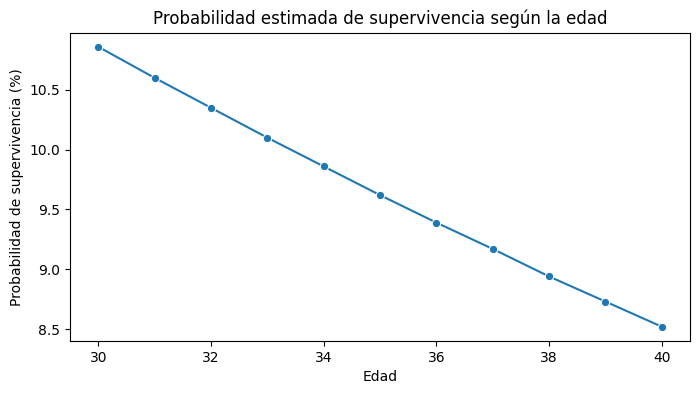

In [76]:
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=resultado_extra,
    x="Edad",
    y="Prob_supervivencia (%)",
    marker="o"
)

plt.title("Probabilidad estimada de supervivencia según la edad")
plt.xlabel("Edad")
plt.ylabel("Probabilidad de supervivencia (%)")

plt.show()

### Conclusión

- Para el perfil analizado —hombre, pasajero de segunda clase, embarcado en Southampton, viajando solo y con una tarifa de 0— el modelo estima una **probabilidad media de supervivencia del 9.65 %** considerando edades comprendidas entre los 30 y los 40 años.
- Las probabilidades individuales disminuyen progresivamente con la edad, pasando de aproximadamente **10.86 % a los 30 años** a **8.52 % a los 40 años**. Este comportamiento es coherente con el coeficiente negativo obtenido previamente para la variable `age` en el modelo de regresión logística.
- Dado que todas las probabilidades estimadas se encuentran claramente por debajo del umbral de clasificación por defecto de **0.5**, el modelo clasificaría todos los registros analizados como **no supervivientes (`survived = 0`)**.
- Este ejercicio muestra también la importancia de aplicar a los nuevos registros exactamente las mismas transformaciones utilizadas durante el entrenamiento: transformación logarítmica de `fare`, codificación de las variables categóricas y escalado mediante el `StandardScaler` previamente ajustado con Train.

## 14. EXTRA: Clasificación multiclase de la clase del pasajero

En este apartado se adapta el problema anterior a un escenario de **clasificación multiclase**.

La nueva variable objetivo será `pclass`, que representa la clase en la que viajaba el pasajero:

- `1`: Primera clase.
- `2`: Segunda clase.
- `3`: Tercera clase.

Por tanto, `pclass` dejará de utilizarse como variable predictora y será sustituida en las features por el target anterior, `survived`.

El objetivo será comprobar cómo puede adaptarse el mismo enfoque de regresión logística a un problema con más de dos clases.

Para evitar modificar los conjuntos utilizados anteriormente, se crearán nuevas parejas `X_train_multi`, `X_test_multi`, `y_train_multi` e `y_test_multi`.

In [77]:
# Creamos el nuevo target multiclase
y_train_multi = X_train["pclass"].copy()
y_test_multi = X_test["pclass"].copy()

print("Distribución del target en Train:")
print(y_train_multi.value_counts().sort_index())

print("\nDistribución del target en Test:")
print(y_test_multi.value_counts().sort_index())

Distribución del target en Train:
pclass
1    163
2    143
3    405
Name: count, dtype: int64

Distribución del target en Test:
pclass
1    51
2    41
3    86
Name: count, dtype: int64


In [78]:
# Copiamos las features para no modificar los conjuntos anteriores
X_train_multi = X_train.drop(columns="pclass").copy()
X_test_multi = X_test.drop(columns="pclass").copy()

# Añadimos el target anterior como nueva feature
X_train_multi["survived"] = y_train.values
X_test_multi["survived"] = y_test.values

In [79]:
print("Features Train multiclase:")
print(X_train_multi.columns.tolist())

print("\nFeatures Test multiclase:")
print(X_test_multi.columns.tolist())

print("\nMismas features:",
      X_train_multi.columns.equals(X_test_multi.columns))

print("\nDimensiones:")
print("X_train_multi:", X_train_multi.shape)
print("X_test_multi:", X_test_multi.shape)
print("y_train_multi:", y_train_multi.shape)
print("y_test_multi:", y_test_multi.shape)

Features Train multiclase:
['age', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'family_group_Small', 'family_group_Solo', 'survived']

Features Test multiclase:
['age', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'family_group_Small', 'family_group_Solo', 'survived']

Mismas features: True

Dimensiones:
X_train_multi: (711, 8)
X_test_multi: (178, 8)
y_train_multi: (711,)
y_test_multi: (178,)


### 14.3 Entrenamiento del modelo de Regresión Logística Multiclase

Una vez construidos los nuevos conjuntos de entrenamiento y test, se entrena un modelo de **Regresión Logística Multiclase** utilizando `pclass` como variable objetivo.

A diferencia del modelo anterior, donde el target únicamente podía tomar dos valores (`0` y `1`), en este caso el modelo debe distinguir entre **tres clases posibles: 1, 2 y 3**.

El entrenamiento se realiza exclusivamente con el conjunto de Train y posteriormente se utilizará el modelo para realizar predicciones sobre Test.


In [80]:
# Creamos el modelo de Regresión Logística Multiclase
log_reg_multi = LogisticRegression(max_iter=5000)

# Entrenamos únicamente con Train
log_reg_multi.fit(X_train_multi, y_train_multi)

# Comprobamos las clases aprendidas por el modelo
print("Clases del modelo:", log_reg_multi.classes_)

Clases del modelo: [1 2 3]


### 14.4 Predicciones y evaluación del modelo

Una vez entrenado el modelo, se realizan las predicciones sobre los conjuntos de Train y Test.

Para evaluar su rendimiento se utiliza el `classification_report`, que permite analizar las métricas de **precision, recall y F1-score** para cada una de las tres clases de pasajeros.

In [81]:
# Realizamos las predicciones
y_pred_train_multi = log_reg_multi.predict(X_train_multi)
y_pred_test_multi = log_reg_multi.predict(X_test_multi)

print("CLASSIFICATION REPORT - TRAIN")
print(classification_report(
    y_train_multi,
    y_pred_train_multi,
    target_names=["Primera clase", "Segunda clase", "Tercera clase"]
))

print("\nCLASSIFICATION REPORT - TEST")
print(classification_report(
    y_test_multi,
    y_pred_test_multi,
    target_names=["Primera clase", "Segunda clase", "Tercera clase"]
))

CLASSIFICATION REPORT - TRAIN
               precision    recall  f1-score   support

Primera clase       0.87      0.93      0.90       163
Segunda clase       0.78      0.32      0.46       143
Tercera clase       0.81      0.96      0.88       405

     accuracy                           0.82       711
    macro avg       0.82      0.74      0.74       711
 weighted avg       0.82      0.82      0.80       711


CLASSIFICATION REPORT - TEST
               precision    recall  f1-score   support

Primera clase       0.96      0.90      0.93        51
Segunda clase       0.67      0.29      0.41        41
Tercera clase       0.73      0.95      0.83        86

     accuracy                           0.79       178
    macro avg       0.79      0.72      0.72       178
 weighted avg       0.78      0.79      0.76       178



### 14.5 Conclusiones

El modelo de Regresión Logística Multiclase obtiene un **accuracy del 82 % en Train y del 79 % en Test**, mostrando un rendimiento relativamente estable entre ambos conjuntos y sin evidencias importantes de sobreajuste.

Sin embargo, el rendimiento varía considerablemente entre las tres clases:

- La **primera clase** presenta un buen comportamiento en Test, con una precisión de **0.96**, un recall de **0.90** y un F1-score de **0.93**.
- La **tercera clase** también es identificada correctamente por el modelo, alcanzando un recall de **0.95** y un F1-score de **0.83**.
- La **segunda clase** es la que presenta mayores dificultades, con un recall de solo **0.29** y un F1-score de **0.41** en Test. Esto indica que el modelo únicamente consigue identificar correctamente una parte reducida de los pasajeros pertenecientes a esta clase.

Esta diferencia también se refleja en el **macro F1-score de 0.72**, inferior al F1-score ponderado de **0.76**, lo que muestra que el buen rendimiento global está influido por las clases que el modelo consigue identificar mejor.

En conjunto, el modelo presenta una capacidad de generalización razonable, pero tiene dificultades para diferenciar la segunda clase de las demás. Esto demuestra la importancia de analizar las métricas de cada clase individualmente en problemas de clasificación multiclase y no basarse únicamente en el accuracy global.